In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

df = pd.read_csv('../data/ran_kpi_data.csv')

# Features only — no labels, no timestamp, no cell_id
kpis = ['rsrp', 'sinr', 'prb_utilization', 'throughput_mbps', 'packet_loss', 'latency_ms']
X = df[kpis]
y = df['is_anomaly']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data loaded:", X_scaled.shape)
print("Anomaly rate:", y.mean().round(3))

Data loaded: (5000, 6)
Anomaly rate: 0.05


In [2]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
iso_forest.fit(X_scaled)

# Predict — IsolationForest returns -1 for anomaly, 1 for normal
preds_raw = iso_forest.predict(X_scaled)
preds = (preds_raw == -1).astype(int)

print("Anomalies detected:", preds.sum())

Anomalies detected: 250


In [3]:
print(classification_report(y, preds, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      4750
     Anomaly       0.82      0.82      0.82       250

    accuracy                           0.98      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.98      0.98      0.98      5000



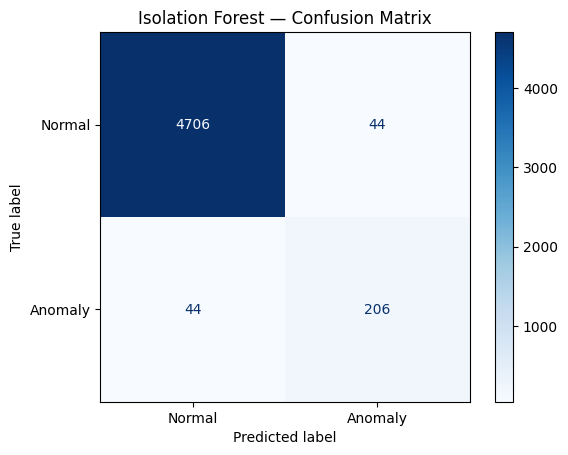

In [4]:
cm = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues')
plt.title('Isolation Forest — Confusion Matrix')
plt.show()

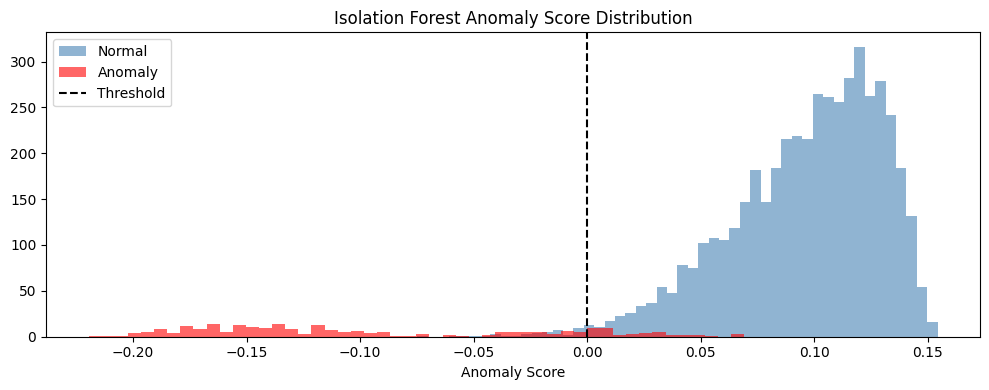

In [5]:
scores = iso_forest.decision_function(X_scaled)

plt.figure(figsize=(10, 4))
plt.hist(scores[y == 0], bins=50, alpha=0.6, label='Normal', color='steelblue')
plt.hist(scores[y == 1], bins=50, alpha=0.6, label='Anomaly', color='red')
plt.axvline(0, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("Models saved")

Models saved
